# Packet Capture and Analysis

## Learning Objective

In this short hands-on activity, we will make sure everyone is up to speed with Jupyter notebooks, and experiment with loading a network packet capture into a Pandas data frame.

You will achieve the following:
* Set up a Jupyter notebook
* Load packet captures into a Pandas data frame
* Manipulate data to extract basic statistics from a packet trace

This notebook assumes that you have basic experience with Python and Jupyter notebooks. If you need additional background for that, please check the additional background resources provided.

## Step 1: Packet Capture

One of the basic sources of data when measuring networked systems is a packet capture (sometimes also called a "packet trace"). The first step of the hands-on will be to perform a small packet capture and perform some basic analysis on that trace.

1. Install [wireshark](https://wireshark.org/), a tool that performs packet capture.

Wireshark is a powerful tool to capture network traffic according to specific filters. Other assignments will explore the use of different filters.

For now, we will perform a capture with a simple filter.

2. The Computer Science Department web server, `www.cs.uchicago.edu`, is at `128.135.24.72` (example).

**Note:** This IP address may change from year to year. To find the current IP address, you can use the following command in your terminal:
```
nslookup www.cs.uchicago.edu
```
or
```
dig www.cs.uchicago.edu +short
```

Set up a capture filter for this address by typing `host <IP_ADDRESS>` into the capture filter (e.g., `host 128.135.24.72`).

3. Start your capture by selecting the network interface that is sending and receiving your network traffic. 

If you are on WiFi, this interface may be called something like `en0`. From the home Wireshark page, it is often clear what the interface is because it shows some traffic activity. 

4. Open a web browser and load `www.cs.uchicago.edu`.

5. Stop and save your trace by clicking the stop icon and saving the file. Save the file both as a `csv` and as a `pcap` (not `pcapng`). To save as a CSV, you should select "export dissected packets" as CSV, under the file menu.



## Step 2: Basic Analysis of the Trace

Before pulling this data into Pandas, let's have a quick look at what is in the trace.

1. How many packets did you capture?
    --> 8910
2. Approximately how long did the capture take?
    --> 47s
3. What is the approximate round trip latency (in milliseconds) between you and the web server?
    --> 13.1ms
4. (Challenging) Were there any lost packets?
    --> I can see two lost packets (TCP Previous segment not captured in info)

## Step 3: Loading and Inspecting the Data

We have provided a library that uses Python's scapy library to load a pcap directly into Pandas. Yet, for convenience in the hands on, we will operate strictly with the CSV.

First, let's load the pandas library, as well as the dataset.

In [1]:
import pandas as pd

Enter some code to load your packet capture below into a pandas data frame called `pcap`.

Let's have a quick look at the data you collected.

In [9]:
PACKETS = "data/packets.csv"

pcap = pd.read_csv(f"{PACKETS}", encoding="cp1252", encoding_errors="replace")
pcap.head(10)

,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,10.190.102.239,224.0.0.251,MDNS,199,Standard query response 0x0000 PTR Jaimnyâ\200...
1,2,0.000003,10.190.102.237,224.0.0.251,MDNS,182,Standard query response 0x0000 PTR \303\226zge...
2,3,0.000005,10.190.103.103,224.0.0.251,MDNS,158,Standard query response 0x0000 PTR AMPHITHEATR...
3,4,0.000006,10.190.102.34,224.0.0.251,MDNS,208,Standard query response 0x0000 PTR BUKONGOâ\20...
4,5,0.000007,10.190.102.251,224.0.0.251,MDNS,230,"Standard query response 0x0000 TXT, cache flus..."
5,6,0.000018,10.190.103.81,224.0.0.251,MDNS,264,"Standard query response 0x0000 TXT, cache flus..."
6,7,0.000019,10.190.103.43,224.0.0.251,MDNS,189,Standard query response 0x0000 PTR Naomiâ\200\...
7,8,0.001017,10.190.102.215,224.0.0.251,MDNS,198,Standard query response 0x0000 PTR Ernieâ\200\...
8,9,0.047209,160.79.104.10,10.190.102.235,TLSv1.2,832,Application Data
9,10,0.047212,160.79.104.10,10.190.102.235,TLSv1.2,93,Application Data


## Step 3: Basic Analysis

1. Compute the total time in your trace.

In [11]:
pcap['Time'].iloc[-1]

np.float64(47.7288069)

**Optional:** You may have let the capture run longer than the time taken to load the web page. Take a closer look at the packet capture or the pandas dataframe to see what may be at the end of the trace if anything. See if you need to alter your computation, and make any fixes to your computation.

2. Compute basic statistics of packet sizes:
  * Mean 
  * Median
  * 90th percentile

(In the assignment, we will explore some more sophisticated analysis.)

In [13]:
mean = pcap['Length'].mean()
median = pcap['Length'].median()
percentile = pcap['Length'].quantile(0.9)

print(f"--- Length Statistics ---\n Mean: {mean}\n Median: {median}\n Percentile: {percentile}")

--- Length Statistics ---
 Mean: 760.7158249158249
 Median: 304.0
 Percentile: 1436.0


## Step 4: Visualization

We can also visualize the data. Plot the following distributions as cumulative distribution functions:
  * Packet size
  * Packet interarrival time (if you have time)

In [19]:
cleaned = pcap['Length'].dropna()
cdf = cleaned.rank(method="max") / len(cleaned) # Take the number of values leq than the 
                                                # given value then divide by length to get a proportion

<Axes: xlabel='Length', ylabel='Proportion'>

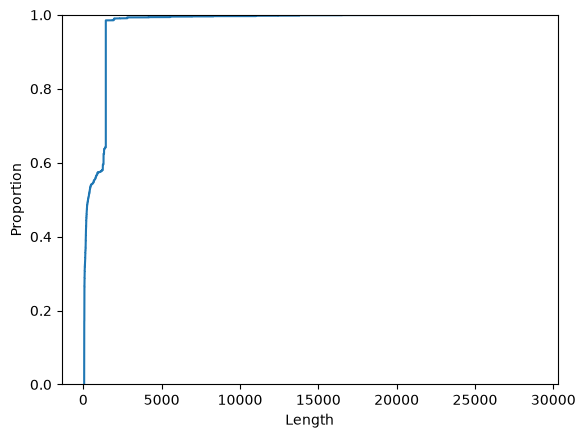

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cleaned = pcap['Length'].dropna()
sns.ecdfplot(x=cleaned)          # seaborn does the ranking